In [12]:
from helper import build_model, create_generators

In [13]:
import pandas as pd
train_df2 = pd.read_csv('csv_data/corrected_df2.csv')
val_df2 = pd.read_csv('csv_data/corrected_val_df2.csv')
train_df2 = train_df2.loc[:, ~train_df2.columns.str.contains('Unnamed', case=False)]
train_df2
val_df2=val_df2.loc[:, ~val_df2.columns.str.contains('Unnamed', case=False)]
val_df2


,filepath,filename,label,source,subfolder,hash,label_idx
0,data/FMD_DATASET/with_mask/simple/simple3378.jpg,simple3378.jpg,with_mask,dataset1_kaggle,simple,2f77bdb0f506a4a39cf92bdc529b09e7,0
1,data/cifar_not_related/cifar_1271.jpg,cifar_1271.jpg,not_related,dataset3_cifar10,cifar_not_related,403d22174ce3f24e1e690951b57e0fee,3
2,data/cifar_not_related/cifar_1880.jpg,cifar_1880.jpg,not_related,dataset3_cifar10,cifar_not_related,e9d373dcfb4823da2cdb122cb270884a,3
3,data/cifar_not_related/cifar_2346.jpg,cifar_2346.jpg,not_related,dataset3_cifar10,cifar_not_related,4bbd6d9be0bebd405ff897eb7d25e31c,3
4,data/cifar_not_related/cifar_1902.jpg,cifar_1902.jpg,not_related,dataset3_cifar10,cifar_not_related,811cfcd18914ccfca12680887f2923e1,3
...,...,...,...,...,...,...,...
2801,data/FMD_DATASET/with_mask/complex/complex224.jpg,complex224.jpg,with_mask,dataset1_kaggle,complex,4cdd80b46fbb3c92c8a7ecbffb011289,0
2802,data/FMD_DATASET/with_mask/simple/simple234.jpg,simple234.jpg,with_mask,dataset1_kaggle,simple,78cec1722d28b65909f8b7aa13cb845c,0
2803,data/cifar_not_related/cifar_0489.jpg,cifar_0489.jpg,not_related,dataset3_cifar10,cifar_not_related,bba4e40ea1e055b3a5ee77e626f8c96a,3
2804,data/cifar_not_related/cifar_1830.jpg,cifar_1830.jpg,not_related,dataset3_cifar10,cifar_not_related,4c6efd482eff4e241f4d02723ff17604,3


In [14]:
IMG_SIZE = (128, 128) 
BATCH_SIZE=32
NUM_CLASSES=4
LEARNING_RATE=0.0001
train_gen2, val_gen2 = create_generators(
    train_df=train_df2,
    val_df=val_df2,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_augmentation=True
)

Found 15504 validated image filenames belonging to 4 classes.
Found 2806 validated image filenames belonging to 4 classes.


In [15]:
model2=build_model( input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES,
    learning_rate=LEARNING_RATE,
    dropout_rate=0.2 )

Adding a Dropout layer with rate 0.2


In [9]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
from tensorflow.keras import callbacks
checkpoint_model2 = callbacks.ModelCheckpoint(
    filepath       = 'MODEL2_V2.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
checkpoint_model_fin_tuning = callbacks.ModelCheckpoint(
    filepath       = 'MODEL2_V2_fine_tuning.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [32]:
history_without_overfit = model2.fit(
    train_gen2,
    epochs=25,
    validation_data=val_gen2,
    callbacks=[checkpoint_model2,early_stop]
)

Epoch 1/25


I0000 00:00:1777928245.530043 3552134 service.cc:152] XLA service 0x7e6d2c0022e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777928245.530057 3552134 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-05-04 22:57:25.571800: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777928245.897716 3552134 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/243 ━━━━━━━━━━━━━━━━━━━━ 23:08 6s/step - accuracy: 0.2812 - loss: 1.4775

I0000 00:00:1777928248.414751 3552134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


115/243 ━━━━━━━━━━━━━━━━━━━━ 2:40 1s/step - accuracy: 0.6921 - loss: 0.7733

...

242/243 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7776 - loss: 0.5781

2026-05-04 23:01:45.143875: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1745', 12 bytes spill stores, 12 bytes spill loads



243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7780 - loss: 0.5772

2026-05-04 23:01:48.330559: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 468 bytes spill stores, 468 bytes spill loads

2026-05-04 23:01:48.397416: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 632 bytes spill stores, 632 bytes spill loads

2026-05-04 23:01:48.398651: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195_0', 916 bytes spill stores, 2128 bytes spill loads

2026-05-04 23:01:48.449323: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 980 bytes spill stores, 980 bytes spill loads

2026-05-04 23:01:56.346602: I


Epoch 1: val_accuracy improved from None to 0.93942, saving model to MODEL2_V2.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8759 - loss: 0.3448 - val_accuracy: 0.9394 - val_loss: 0.1882
Epoch 2/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9374 - loss: 0.1788
Epoch 2: val_accuracy improved from 0.93942 to 0.95510, saving model to MODEL2_V2.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 66s 271ms/step - accuracy: 0.9388 - loss: 0.1728 - val_accuracy: 0.9551 - val_loss: 0.1490
Epoch 3/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9482 - loss: 0.1498
Epoch 3: val_accuracy improved from 0.95510 to 0.95902, saving model to MODEL2_V2.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 243ms/step - accuracy: 0.9489 - loss: 0.1479 - val_accuracy: 0.9590 - val_loss: 0.1398
Epoch 4/25
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9477 - loss: 0.1512
Epoch 4: val_accuracy did not improve from 0.95902
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 242ms/step - accuracy: 0.9518 - 

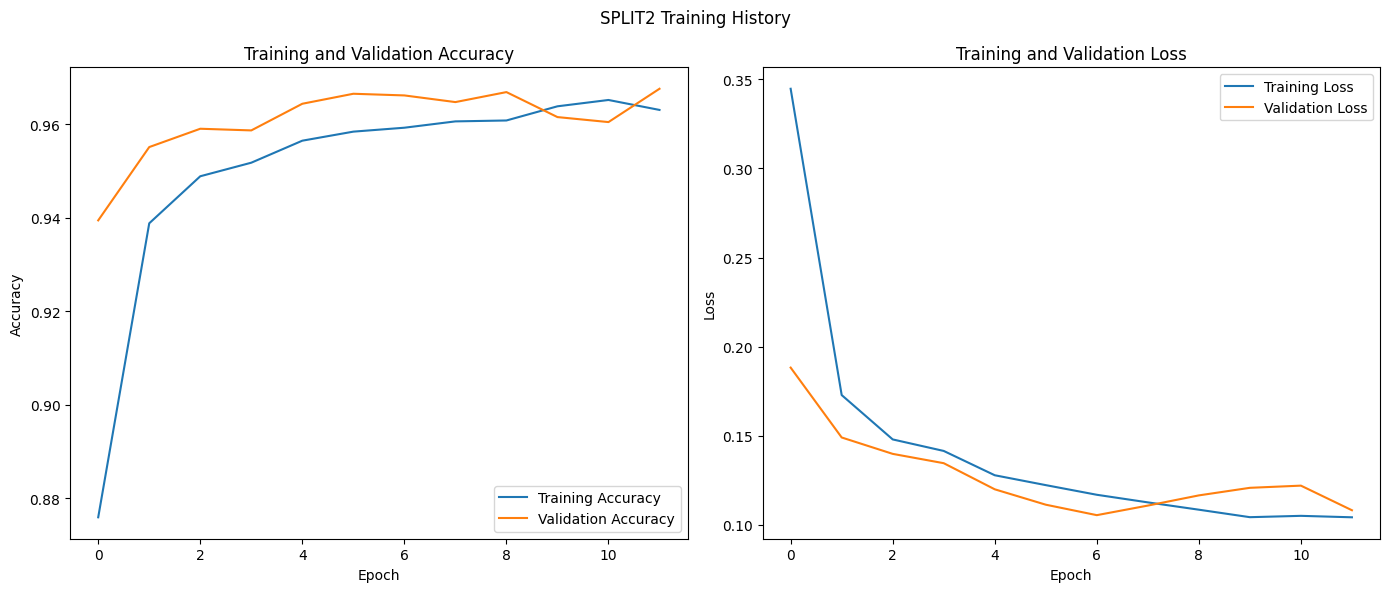

In [33]:
from helper import plot_results

plot_results(history_without_overfit, title="SPLIT2 Training History")

In [6]:
import gc
tf.keras.backend.clear_session()
gc.collect()

0

In [5]:
import tensorflow as tf

def add_fine_tuning(model, train_gen, val_gen, fine_tune_epochs=5):
    base_model = model.layers[1]  
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False
        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
        return model.fit(
        train_gen, 
        epochs=fine_tune_epochs,
        validation_data=val_gen,
        callbacks=[checkpoint_model2]
)
model2 = tf.keras.models.load_model('MODEL2_V2.keras')

I0000 00:00:1777933940.662517 3581505 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9931 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


In [9]:
history_phase2 = add_fine_tuning(model2, train_gen2, val_gen2, fine_tune_epochs=5)

Epoch 1/5


I0000 00:00:1777934109.856243 3582289 service.cc:152] XLA service 0x759298019000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777934109.856258 3582289 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti, Compute Capability 8.9
2026-05-05 00:35:10.094248: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777934111.333828 3582289 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-05-05 00:35:12.290241: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7785', 4 bytes spill stores, 4 bytes spill loads



  3/485 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.7257 - loss: 0.7650   

I0000 00:00:1777934118.570634 3582289 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


266/485 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step - accuracy: 0.8311 - loss: 0.4713

...

301/485 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - accuracy: 0.8373 - loss: 0.4547

/home/macierz/s211719/facemask_env/lib/python3.10/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8606 - loss: 0.3921

2026-05-05 00:36:23.383041: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 204 bytes spill stores, 204 bytes spill loads

2026-05-05 00:36:23.399891: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195_0', 464 bytes spill stores, 1372 bytes spill loads

2026-05-05 00:36:23.590244: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 5616 bytes spill stores, 5612 bytes spill loads

2026-05-05 00:36:23.759852: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1195', 5372 bytes spill stores, 5352 bytes spill loads

2026-05-05 00:36:31.85769


Epoch 1: val_accuracy improved from None to 0.97434, saving model to MODEL2_V2.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 91s 156ms/step - accuracy: 0.9082 - loss: 0.2629 - val_accuracy: 0.9743 - val_loss: 0.0978
Epoch 2/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9544 - loss: 0.1416
Epoch 2: val_accuracy improved from 0.97434 to 0.97719, saving model to MODEL2_V2.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 62s 128ms/step - accuracy: 0.9557 - loss: 0.1346 - val_accuracy: 0.9772 - val_loss: 0.0858
Epoch 3/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9622 - loss: 0.1130
Epoch 3: val_accuracy did not improve from 0.97719
485/485 ━━━━━━━━━━━━━━━━━━━━ 60s 124ms/step - accuracy: 0.9641 - loss: 0.1078 - val_accuracy: 0.9772 - val_loss: 0.0767
Epoch 4/5
485/485 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9628 - loss: 0.1043
Epoch 4: val_accuracy improved from 0.97719 to 0.98040, saving model to MODEL2_V2.keras
485/485 ━━━━━━━━━━━━━━━━━━━━ 61s 126ms/step - accuracy: 0.9651 - l

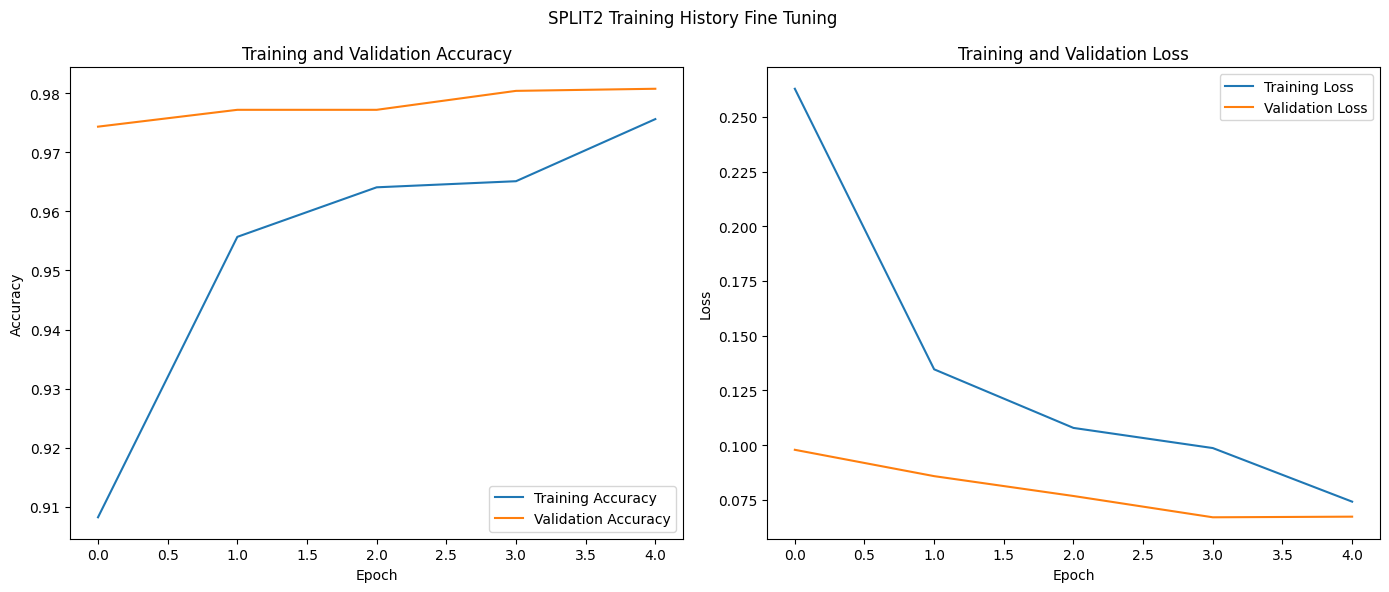

In [11]:
from helper import plot_results

plot_results(history_phase2, title="SPLIT2 Training History Fine Tuning ")